In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample, butter, filtfilt, find_peaks
from scipy.interpolate import CubicSpline

path =r"C:\Dania's files~\Codes\triago_app\draft_filter\Data9.csv"
df = pd.read_csv(path, sep=',', header=0)
df.head()

,Time (s),PPG_Red,PPG_IR,PPG_Green,ECG,Temp_Ambient,Temp_Object,SpO2_Ground_Truth
0,0.0000,33691,35256,77,1401,25.47,23.64,96
1,0.0025,33708,35250,69,1504,25.47,23.64,96
2,0.0050,33734,35221,77,1361,25.47,23.64,96
3,0.0075,33720,35249,76,992,25.47,23.64,96
4,0.0100,33715,35251,89,886,25.47,23.64,96


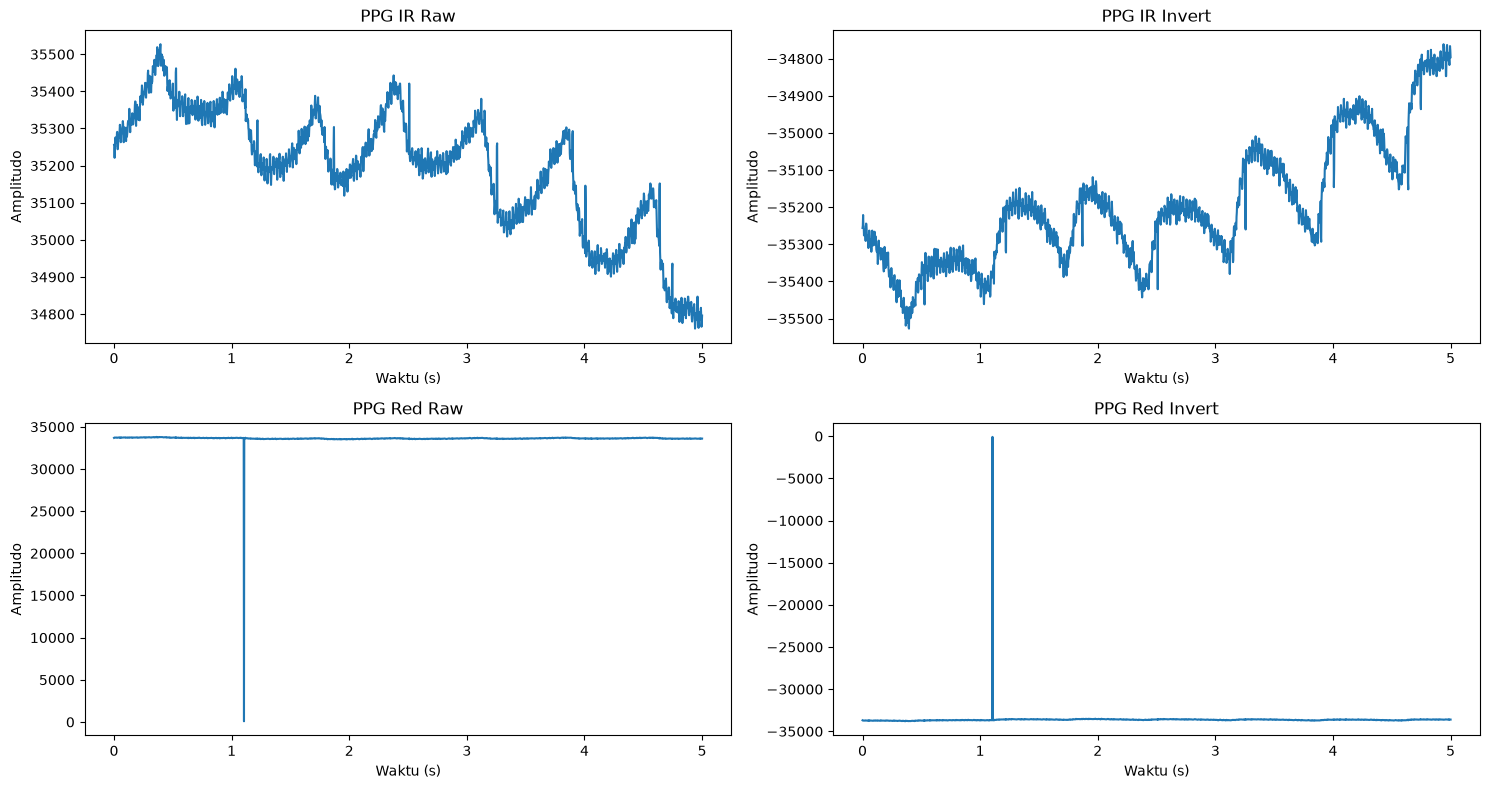

In [21]:
time = df['Time (s)'].copy()
ppg_ir = df['PPG_IR'].copy()
ppg_red = df['PPG_Red'].copy()
durasi_real = time <= 5

fig,ax = plt.subplots(2, 2, figsize=(15, 8))
ax = ax.flatten()

ax[0].plot(time[durasi_real], ppg_ir[durasi_real])
ax[0].set_title('PPG IR Raw')
ax[0].set_xlabel('Waktu (s)')
ax[0].set_ylabel('Amplitudo')

ax[1].plot(time[durasi_real], -ppg_ir[durasi_real])
ax[1].set_title('PPG IR Invert')
ax[1].set_xlabel('Waktu (s)')
ax[1].set_ylabel('Amplitudo')

ax[2].plot(time[durasi_real], ppg_red[durasi_real])
ax[2].set_title('PPG Red Raw')
ax[2].set_xlabel('Waktu (s)')
ax[2].set_ylabel('Amplitudo')

ax[3].plot(time[durasi_real], -ppg_red[durasi_real])
ax[3].set_title('PPG Red Invert')
ax[3].set_xlabel('Waktu (s)')
ax[3].set_ylabel('Amplitudo')

plt.tight_layout()
plt.show()


In [22]:

# init
fs = 400
target_fs = 125

# invert
ppg_ir = -ppg_ir
ppg_red = -ppg_red

# resample
num_samples = int(len(df)*target_fs/fs)
ppg_ir_resample = resample(ppg_ir, num_samples)
ppg_red_resample = resample(ppg_red, num_samples)
time_resampled = np.linspace(time.iloc[0], time.iloc[-1], num_samples)


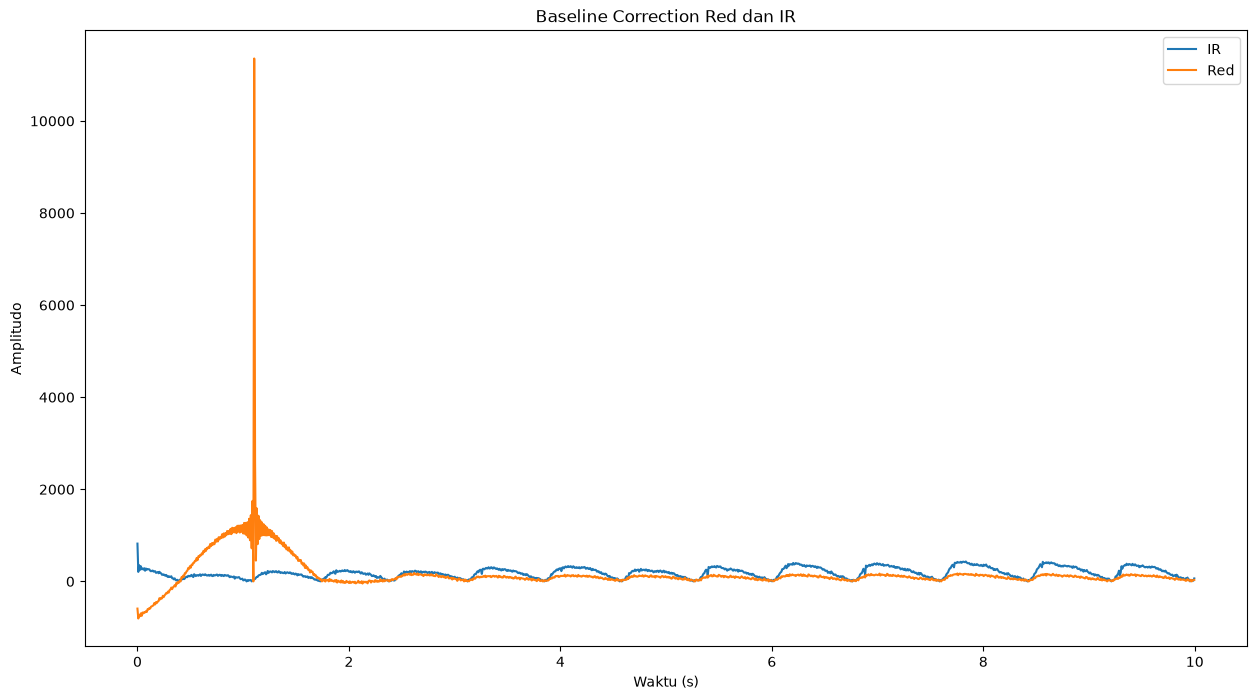

In [23]:
# baseline correction + AC/DC separation
def baseline_correction(time, x, fs):
    min_distance = int(0.5 * fs) 
    peaks, _ = find_peaks(-x, distance=min_distance, prominence=0.1)

    if len(peaks) < 2:
        raise ValueError('lembah terlalu sedikit untuk interpolasi')
    
    t_val = time[peaks]
    s_val = x[peaks]

    cs = CubicSpline(t_val, s_val, bc_type='natural')
    baseline_dc = cs(time)
    x_corrected = x - baseline_dc

    return x_corrected, baseline_dc, t_val, s_val

ppg_ir_corrected, dc_ir_spline, t_val_ir, s_val_ir = baseline_correction(time_resampled, ppg_ir_resample, target_fs)
ppg_red_corrected, dc_red_spline, t_val_red, s_val_red = baseline_correction(time_resampled, ppg_red_resample, target_fs)

durasi = time_resampled <= 10

plt.figure(figsize=(15, 8))
plt.plot(time_resampled[durasi], ppg_ir_corrected[durasi])
plt.plot(time_resampled[durasi], ppg_red_corrected[durasi])
plt.title('Baseline Correction Red dan IR')
plt.xlabel('Waktu (s)')
plt.ylabel('Amplitudo')
plt.legend(['IR', 'Red'])
plt.show()

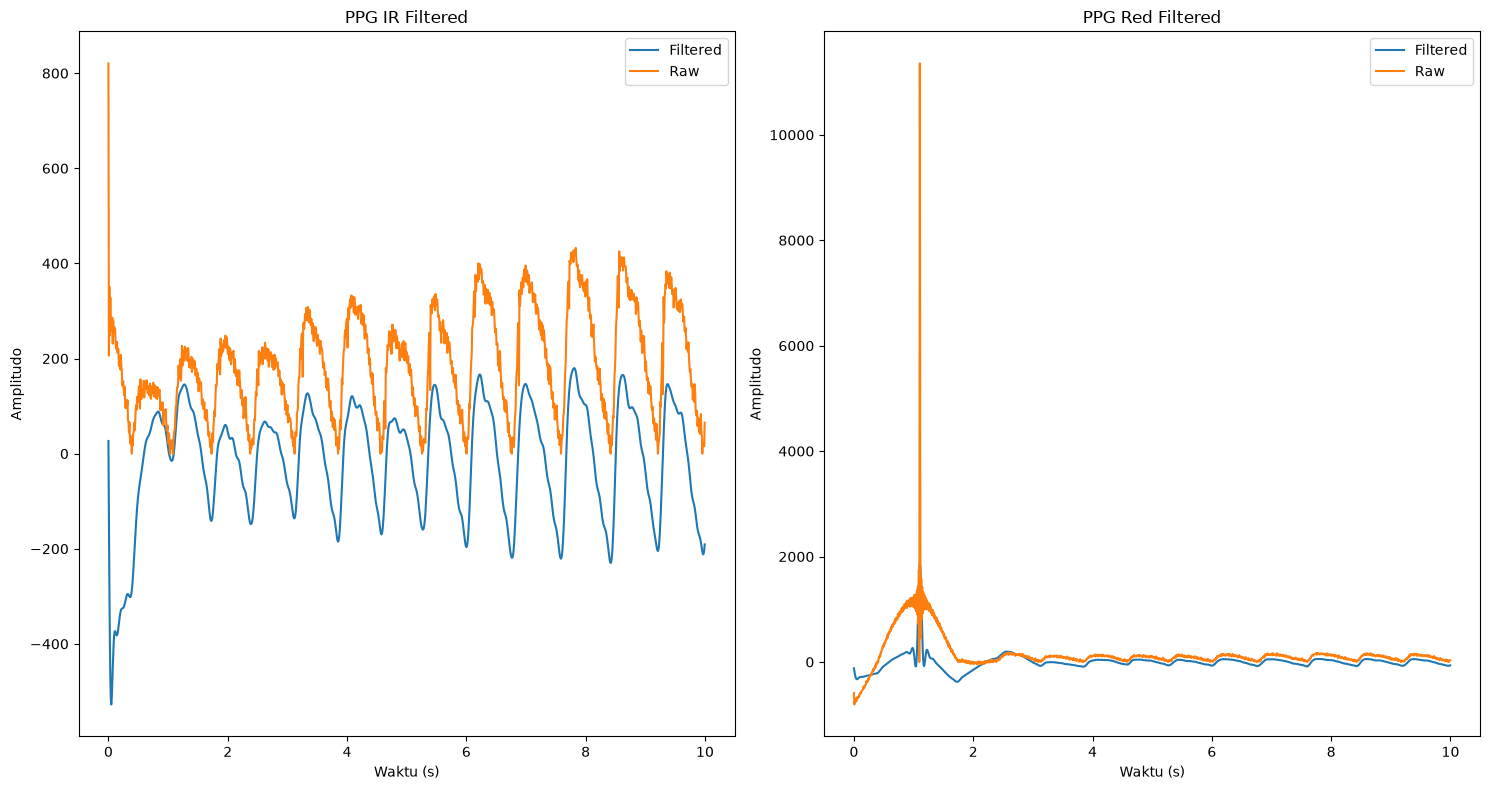

In [24]:
def bpf(x, low_cut = 0.5, high_cut = 10, fs = 125, order=4):
    nyq = 0.5 * fs
    low = low_cut / nyq
    high = high_cut / nyq

    b, a = butter(order, [low, high], btype='bandpass', analog=False)
    clean_ppg = filtfilt(b, a, x)
    return clean_ppg


ir_clean = bpf(ppg_ir_corrected)
red_clean = bpf(ppg_red_corrected)

fig, ax = plt.subplots(1,2, figsize=(15,8))
ax = ax.flatten()

ax[0].plot(time_resampled[durasi], ir_clean[durasi])
ax[0].plot(time_resampled[durasi], ppg_ir_corrected[durasi])
ax[0].set_title('PPG IR Filtered')
ax[0].set_xlabel('Waktu (s)')
ax[0].set_ylabel('Amplitudo')
ax[0].legend(['Filtered', 'Raw'])

ax[1].plot(time_resampled[durasi], red_clean[durasi])
ax[1].plot(time_resampled[durasi], ppg_red_corrected[durasi])
ax[1].set_title('PPG Red Filtered')
ax[1].set_xlabel('Waktu (s)')
ax[1].set_ylabel('Amplitudo')
ax[1].legend(['Filtered', 'Raw'])

plt.tight_layout()
plt.show()

In [25]:
def calculate_ac_p2p(ac_signal, fs=125):
    # jarak minimal antar detak jantung (~120 BPM)
    min_distance = int(0.5 * fs)
    
    # cari indeks puncak sistolik dan lembah diastolik
    peaks, _ = find_peaks(ac_signal, distance=min_distance, prominence=10)
    troughs, _ = find_peaks(-ac_signal, distance=min_distance, prominence=10)
    
    # pastikan jumlah detak berpasangan
    num_beats = min(len(peaks), len(troughs))
    if num_beats == 0:
        return 0
        
    # hitung selisih nilai dari setiap detak
    p2p_values = []
    for i in range(num_beats):
        amp = ac_signal[peaks[i]] - ac_signal[troughs[i]]
        p2p_values.append(amp)
        
    # kembalikan nilai rata-rata amplitudo p2p
    return np.mean(p2p_values)

# ekstrak nilai ac dari ppg menggunakan fungsi p2p
p2p_ac_ir = calculate_ac_p2p(ir_clean, fs=125)
p2p_ac_red = calculate_ac_p2p(red_clean, fs=125)

print(f'Nilai AC IR: {p2p_ac_ir}')
print(f'Nilai AC Red: {p2p_ac_red}')

mean_dc_ir = np.mean(np.abs(dc_ir_spline))
mean_dc_red = np.mean(np.abs(dc_red_spline))

print(f'Nilai DC IR: {mean_dc_ir}')
print(f'Nilai DC Red: {mean_dc_red}')

# ekstrak index perfusi darah
pi_ir = p2p_ac_ir / mean_dc_ir
pi_red = p2p_ac_red / mean_dc_red

print(f'Nilai PI IR: {pi_ir}')
print(f'Nilai PI Red: {pi_red}')

# ekstrak saturasi oksgien
r_ratio = (p2p_ac_red / mean_dc_red)/(p2p_ac_ir / mean_dc_ir)
# spo2 = 65.7146 * (r_ratio**2) + (-73.3602) * r_ratio + 117.4598
# spo2 = -10.0412 * (r_ratio**2) + (7.5998) * r_ratio + 96.4557
spo2 = -12.2075 * (r_ratio**2) + (16.5751) * r_ratio + 90.5733
spo2 = np.clip(spo2, 0, 100)

print(f'Nilai Saturasi Oksigen: {spo2}')

Nilai AC IR: 369.76595961751013
Nilai AC Red: 260.4033012094267
Nilai DC IR: 34916.50356644932
Nilai DC Red: 33689.60897651247
Nilai PI IR: 0.010590005351303618
Nilai PI Red: 0.007729484227346573
Nilai Saturasi Oksigen: 96.16788980627672
